<a href="https://colab.research.google.com/github/unnati-negi/GENAI/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


In [ ]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Linear(256,64),
            nn.ReLU(),
            nn.Linear(64,32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Sigmoid()
        )

    def forward(self,x):

        latent = self.encoder(x)
        output = self.decoder(latent)

        return output, latent

In [ ]:
model = Autoencoder()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

In [ ]:
print("Training Basic Autoencoder")

for epoch in range(epochs):

    for images,_ in train_loader:

        images = images.view(-1,784)

        outputs,_ = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())



Training Basic Autoencoder
Epoch: 0 Loss: 0.029901569709181786
Epoch: 1 Loss: 0.022424854338169098
Epoch: 2 Loss: 0.016801808029413223
Epoch: 3 Loss: 0.01633368618786335
Epoch: 4 Loss: 0.014257093891501427
Epoch: 5 Loss: 0.014462143182754517
Epoch: 6 Loss: 0.012689465656876564
Epoch: 7 Loss: 0.011327285319566727
Epoch: 8 Loss: 0.01180998608469963
Epoch: 9 Loss: 0.009876140393316746


In [ ]:
print("\nTraining Denoising Autoencoder")

for epoch in range(epochs):

    for images,_ in train_loader:

        images = images.view(-1,784)

        noisy_images = images + 0.1 * torch.randn_like(images)
        noisy_images = torch.clamp(noisy_images,0.,1.)

        outputs,_ = model(noisy_images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())



Training Denoising Autoencoder
Epoch: 0 Loss: 0.010062113404273987
Epoch: 1 Loss: 0.009776798076927662
Epoch: 2 Loss: 0.009090859442949295
Epoch: 3 Loss: 0.008907974697649479
Epoch: 4 Loss: 0.009069043211638927
Epoch: 5 Loss: 0.008124400861561298
Epoch: 6 Loss: 0.007506475318223238
Epoch: 7 Loss: 0.007946489378809929
Epoch: 8 Loss: 0.008714006282389164
Epoch: 9 Loss: 0.008050378412008286


In [ ]:

def sparse_loss(hidden, rho=0.05):

    rho_hat = torch.mean(hidden, dim=0)

    kl = rho * torch.log(rho / rho_hat) + (1-rho) * torch.log((1-rho)/(1-rho_hat))

    return torch.sum(kl)


Training Sparse Autoencoder
Epoch: 0 Loss: nan
Epoch: 1 Loss: nan
Epoch: 2 Loss: nan
Epoch: 3 Loss: nan
Epoch: 4 Loss: nan
Epoch: 5 Loss: nan
Epoch: 6 Loss: nan
Epoch: 7 Loss: nan
Epoch: 8 Loss: nan
Epoch: 9 Loss: nan


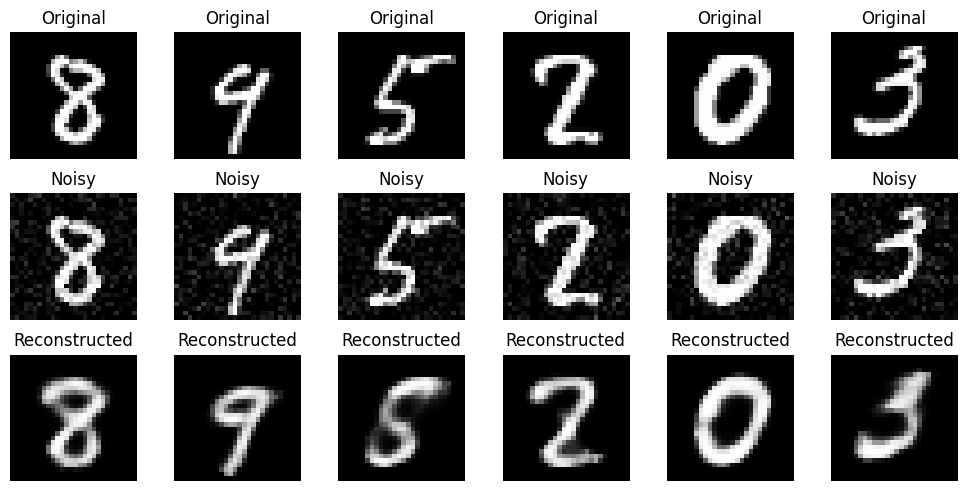

In [ ]:
print("\nTraining Sparse Autoencoder")

beta = 1e-3

for epoch in range(epochs):

    for images,_ in train_loader:

        images = images.view(-1,784)

        outputs, hidden = model(images)

        recon_loss = criterion(outputs, images)

        sparsity_penalty = sparse_loss(hidden)

        loss = recon_loss + beta * sparsity_penalty

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())





def show_results(model):

    model.eval()

    with torch.no_grad():

        images,_ = next(iter(train_loader))

        images = images.view(-1,784)

        noisy = images + 0.1 * torch.randn_like(images)
        noisy = torch.clamp(noisy,0.,1.)

        outputs,_ = model(noisy)

    fig,axs = plt.subplots(3,6, figsize=(10,5))

    for i in range(6):

        axs[0,i].imshow(images[i].view(28,28).numpy(), cmap="gray")
        axs[0,i].set_title("Original")
        axs[0,i].axis("off")

        axs[1,i].imshow(noisy[i].view(28,28).numpy(), cmap="gray")
        axs[1,i].set_title("Noisy")
        axs[1,i].axis("off")

        axs[2,i].imshow(outputs[i].view(28,28).numpy(), cmap="gray")
        axs[2,i].set_title("Reconstructed")
        axs[2,i].axis("off")

    plt.tight_layout()
    plt.show()






show_results(model)

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 64)

        # Latent space
        self.fc_mu = nn.Linear(64, 20)
        self.fc_logvar = nn.Linear(64, 20)

        # Decoder
        self.fc3 = nn.Linear(20, 64)
        self.fc4 = nn.Linear(64, 256)
        self.fc5 = nn.Linear(256, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        h = self.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.relu(self.fc3(z))
        h = self.relu(self.fc4(h))
        return self.sigmoid(self.fc5(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    reconstruction = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction + kl_divergence

In [ ]:
model = VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 10

print("Training Variational Autoencoder")

for epoch in range(epochs):
    for images, _ in train_loader:

        images = images.view(-1, 784)

        recon, mu, logvar = model(images)

        loss = vae_loss(recon, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Training Variational Autoencoder
Epoch: 0 Loss: 12498.50390625
Epoch: 1 Loss: 13080.66796875
Epoch: 2 Loss: 12455.3798828125
Epoch: 3 Loss: 12026.30078125
Epoch: 4 Loss: 12106.216796875
Epoch: 5 Loss: 11458.2978515625
Epoch: 6 Loss: 12492.970703125
Epoch: 7 Loss: 11960.103515625
Epoch: 8 Loss: 12063.0634765625
Epoch: 9 Loss: 11626.9677734375


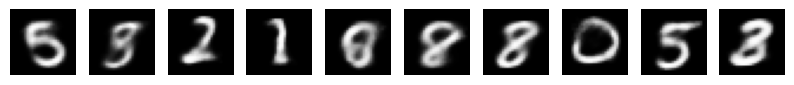

In [ ]:
def generate_images(model, n=10):

    model.eval()

    with torch.no_grad():
        z = torch.randn(n, 20)
        generated = model.decode(z)

    fig, ax = plt.subplots(1, n, figsize=(10,2))

    for i in range(n):
        ax[i].imshow(generated[i].view(28,28).numpy(), cmap="gray")
        ax[i].axis("off")

    plt.show()

generate_images(model)